In [6]:
#part a
import numpy as np

Q = np.array([
    [-1,  1,  0,  0],
    [ 0, -1,  1,  0],
    [ 0,  0, -1,  1],
    [ 1,  0,  0, -1]
], dtype=float)

eigvals = np.linalg.eigvals(Q)
print(eigvals)

[-2.00000000e+00+0.j -1.00000000e+00+1.j -1.00000000e+00-1.j
 -1.87323557e-16+0.j]


In [4]:
#part d
import sympy as sp

t = sp.symbols('t')

#define functions
y1 = sp.Function('y1')(t)
y2 = sp.Function('y2')(t)
y3 = sp.Function('y3')(t)
y4 = sp.Function('y4')(t)

#define master equations
eq1 = sp.Eq(sp.diff(y1, t), y4 - y1)
eq2 = sp.Eq(sp.diff(y2, t), y1 - y2)
eq3 = sp.Eq(sp.diff(y3, t), y2 - y3)
eq4 = sp.Eq(sp.diff(y4, t), y3 - y4)

#solve system with initial conditions
sol = sp.dsolve(
    [eq1, eq2, eq3, eq4],
    ics={
        y1.subs(t,0): 1/3,
        y2.subs(t,0): 2/3,
        y3.subs(t,0): 0,
        y4.subs(t,0): 0
    }
)

#sol
y1_clean = sp.nsimplify(sol[0])
print(y1_clean)

Eq(y1(t), 1/4 - exp(-t)*sin(t)/3 + exp(-t)*cos(t)/6 - exp(-2*t)/12)


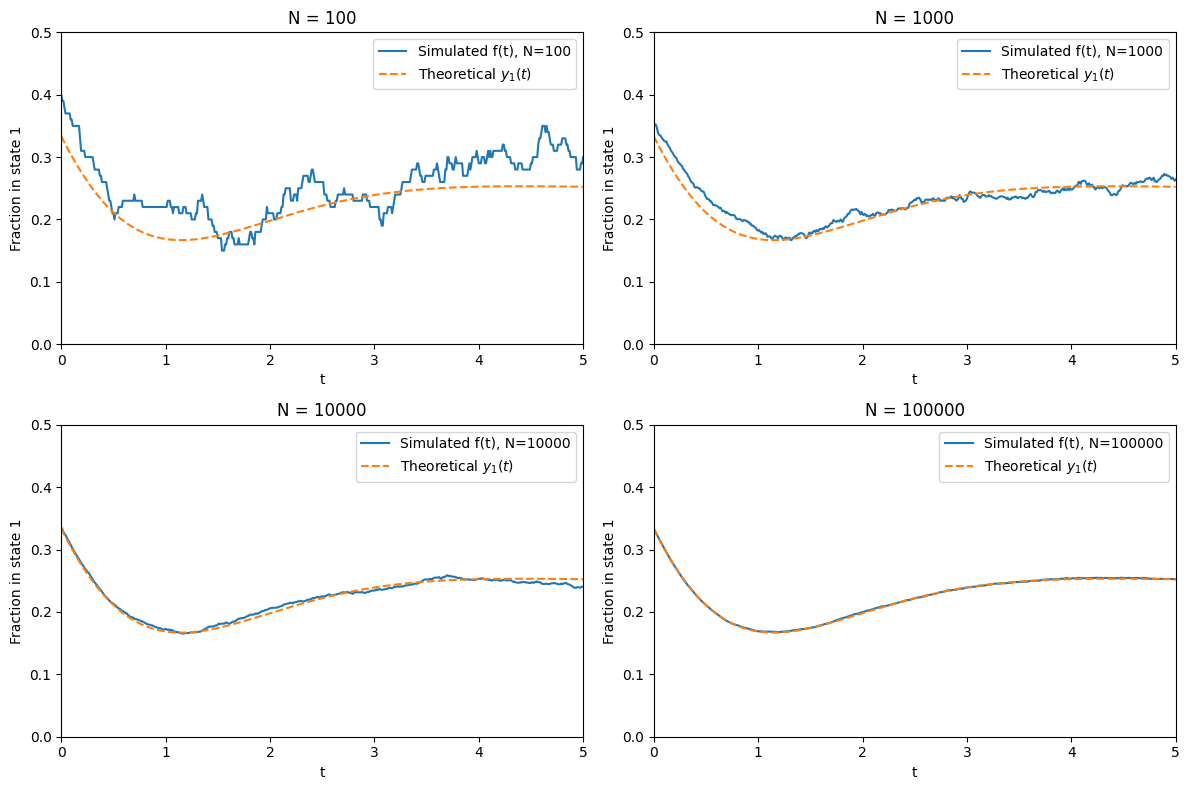

In [8]:
#part e
import matplotlib.pyplot as plt

#theoretical solution
def y1_theory(t):
    return (1/4
            - (1/3)*np.exp(-t)*np.sin(t)
            + (1/6)*np.exp(-t)*np.cos(t)
            - (1/12)*np.exp(-2*t))

#simulate N independent chains on [0,5]
def simulate_fraction_state1(N, t_max=5, num_points=501, seed=None):
    rng = np.random.default_rng(777)

    #time grid
    t_vals = np.linspace(0, t_max, num_points)
    dt = t_vals[1] - t_vals[0]

    #initial states:
    #state 1 with prob 1/3, state 2 with prob 2/3
    init = rng.choice([1, 2], size=N, p=[1/3, 2/3])

    #current states
    states = init.copy()

    #store fraction in state 1
    f_vals = np.empty(num_points)
    f_vals[0] = np.mean(states == 1)

    #evolve through time grid
    for k in range(1, num_points):
        #number of jumps each chain makes in this time step
        jumps = rng.poisson(dt, size=N)

        #move forward around the 4-cycle
        #convert to 0,1,2,3 then back to 1,2,3,4
        states = ((states - 1 + jumps) % 4) + 1

        #fraction in state 1
        f_vals[k] = np.mean(states == 1)

    return t_vals, f_vals

#values of N
N_values = [100, 1000, 10000, 100000]

#plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, N in zip(axes, N_values):
    t_vals, f_vals = simulate_fraction_state1(N, seed=123)

    ax.plot(t_vals, f_vals, label=f"Simulated f(t), N={N}")
    ax.plot(t_vals, y1_theory(t_vals), '--', label="Theoretical $y_1(t)$")

    ax.set_xlim(0, 5)
    ax.set_ylim(0, 0.5)
    ax.set_title(f"N = {N}")
    ax.set_xlabel("t")
    ax.set_ylabel("Fraction in state 1")
    ax.legend()

plt.tight_layout()
plt.savefig("hw8-pbm1e.png", dpi=300, bbox_inches="tight")
plt.show()